## Step 3: Fast focal-only screening and final training

In [25]:
import copy
import json
import pickle
import colorsys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window, from_bounds, bounds as window_bounds
from rasterio.enums import Resampling

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score

import segmentation_models_pytorch as smp

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
print("AMP enabled:", use_amp)

Using device: cuda
AMP enabled: True


C:\Users\wattd\AppData\Local\Temp\ipykernel_2712\709063569.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [27]:
ARTIFACTS_DIR = Path("step2_artifacts")

with open(ARTIFACTS_DIR / "train_index.pkl", "rb") as f:
    train_index = pickle.load(f)

with open(ARTIFACTS_DIR / "val_index.pkl", "rb") as f:
    val_index = pickle.load(f)

with open(ARTIFACTS_DIR / "test_index.pkl", "rb") as f:
    test_index = pickle.load(f)

with open(ARTIFACTS_DIR / "step2_bundle.json", "r") as f:
    step2_bundle = json.load(f)

DATA_DIR = Path(step2_bundle["data_dir"])
MULTI_DIR = Path(step2_bundle["multi_dir"])
DEM_DIR = Path(step2_bundle["dem_dir"])
MASK_DIR = Path(step2_bundle["mask_dir"])

PATCH_SIZE = step2_bundle["patch_size"]
BATCH_SIZE = step2_bundle["batch_size"]
MULTI_SCALE = step2_bundle["multi_scale"]
dem_mean = step2_bundle["dem_mean"]
dem_std = step2_bundle["dem_std"]

BAND_NAMES = step2_bundle["band_names"]
BAND_TO_IDX = step2_bundle["band_to_idx"]

print("Loaded Step 2 artifacts successfully.")
print("Train patches:", len(train_index))
print("Val patches:", len(val_index))
print("Test patches:", len(test_index))
print("Feature sets:", step2_bundle["feature_sets"])

Loaded Step 2 artifacts successfully.
Train patches: 1200
Val patches: 520
Test patches: 834
Feature sets: {'raw_s2': 10, 'raw_s2_dem': 11, 'raw_idx_dem': 16, 'raw_idx_hsv_dem': 19}


In [29]:
class FloodPatchDataset(Dataset):
    def __init__(self, patch_index, patch_size=256, feature_set="raw_s2", dem_mean=0.0, dem_std=1.0, multi_scale=10000.0):
        self.patch_index = patch_index
        self.patch_size = patch_size
        self.feature_set = feature_set
        self.dem_mean = dem_mean
        self.dem_std = dem_std if dem_std > 0 else 1.0
        self.multi_scale = multi_scale

    def __len__(self):
        return len(self.patch_index)

    def _read_mask_patch(self, mask_path, top, left, height, width):
        with rasterio.open(mask_path) as src:
            win = Window(left, top, width, height)
            patch = src.read(1, window=win)
            bounds = window_bounds(win, src.transform)
            ref_crs = src.crs
        return patch, bounds, ref_crs

    def _read_dem_patch(self, dem_path, top, left, height, width):
        with rasterio.open(dem_path) as src:
            win = Window(left, top, width, height)
            patch = src.read(1, window=win).astype(np.float32)
        return patch

    def _read_multi_patch_from_bounds(self, multi_path, bounds, ref_height, ref_width, ref_crs):
        with rasterio.open(multi_path) as src:
            assert src.crs == ref_crs, "CRS mismatch between multi and reference mask"
            win = from_bounds(*bounds, transform=src.transform)
            win = win.round_offsets().round_lengths()
            patch = src.read(window=win, out_shape=(src.count, ref_height, ref_width), resampling=Resampling.bilinear).astype(np.float32)
        return patch

    def _pad_2d(self, arr):
        H, W = arr.shape
        out = np.zeros((self.patch_size, self.patch_size), dtype=arr.dtype)
        out[:H, :W] = arr
        return out

    def _pad_3d(self, arr):
        C, H, W = arr.shape
        out = np.zeros((C, self.patch_size, self.patch_size), dtype=arr.dtype)
        out[:, :H, :W] = arr
        return out

    def _norm_index(self, a, b):
        return (a - b) / (a + b + 1e-6)

    def _compute_hsv_nasa(self, multi):
        r = multi[BAND_TO_IDX["B12"]]
        g = multi[BAND_TO_IDX["B08"]]
        b = multi[BAND_TO_IDX["B04"]]
        rgb = np.stack([r, g, b], axis=-1)
        rgb = np.clip(rgb, 0, 1)
        H, W, _ = rgb.shape
        hsv = np.zeros((3, H, W), dtype=np.float32)
        for i in range(H):
            for j in range(W):
                hh, ss, vv = colorsys.rgb_to_hsv(float(rgb[i, j, 0]), float(rgb[i, j, 1]), float(rgb[i, j, 2]))
                hsv[0, i, j] = hh
                hsv[1, i, j] = ss
                hsv[2, i, j] = vv
        return hsv

    def _build_features(self, multi, dem):
        multi = multi / self.multi_scale
        green = multi[BAND_TO_IDX["B03"]]
        red   = multi[BAND_TO_IDX["B04"]]
        nir   = multi[BAND_TO_IDX["B08"]]
        swir1 = multi[BAND_TO_IDX["B11"]]
        swir2 = multi[BAND_TO_IDX["B12"]]

        ndwi = self._norm_index(green, nir)
        mndwi = self._norm_index(green, swir1)
        swi = self._norm_index(nir, swir1)
        awei_sh = 4.0 * green - (0.25 * nir + 6.75 * swir2)
        awei_nsh = green + red - 2.0 * swir2

        dem_std = (dem - self.dem_mean) / self.dem_std
        dem_std = dem_std.astype(np.float32)

        if self.feature_set == "raw_s2":
            x = multi
        elif self.feature_set == "raw_s2_dem":
            x = np.concatenate([multi, dem_std[None, ...]], axis=0)
        elif self.feature_set == "raw_idx_dem":
            idx_stack = np.stack([ndwi, mndwi, swi, awei_sh, awei_nsh], axis=0).astype(np.float32)
            x = np.concatenate([multi, idx_stack, dem_std[None, ...]], axis=0)
        elif self.feature_set == "raw_idx_hsv_dem":
            hsv = self._compute_hsv_nasa(multi)
            idx_stack = np.stack([ndwi, mndwi, swi, awei_sh, awei_nsh], axis=0).astype(np.float32)
            x = np.concatenate([multi, idx_stack, hsv, dem_std[None, ...]], axis=0)
        else:
            raise ValueError(f"Unknown feature_set: {self.feature_set}")

        return x.astype(np.float32)

    def __getitem__(self, idx):
        item = self.patch_index[idx]
        top, left = item["top"], item["left"]
        height, width = item["height"], item["width"]
        mask, bounds, ref_crs = self._read_mask_patch(item["mask_path"], top, left, height, width)
        dem = self._read_dem_patch(item["dem_path"], top, left, height, width)
        multi = self._read_multi_patch_from_bounds(item["multi_path"], bounds, height, width, ref_crs)
        x = self._build_features(multi, dem)
        mask = (mask > 0).astype(np.float32)
        x = self._pad_3d(x)
        y = self._pad_2d(mask)[None, ...]
        return torch.from_numpy(x), torch.from_numpy(y)

In [30]:
train_ds_raw = FloodPatchDataset(train_index, patch_size=PATCH_SIZE, feature_set="raw_s2", dem_mean=dem_mean, dem_std=dem_std)
val_ds_raw   = FloodPatchDataset(val_index, patch_size=PATCH_SIZE, feature_set="raw_s2", dem_mean=dem_mean, dem_std=dem_std)
test_ds_raw  = FloodPatchDataset(test_index, patch_size=PATCH_SIZE, feature_set="raw_s2", dem_mean=dem_mean, dem_std=dem_std)

train_ds_raw_dem = FloodPatchDataset(train_index, patch_size=PATCH_SIZE, feature_set="raw_s2_dem", dem_mean=dem_mean, dem_std=dem_std)
val_ds_raw_dem   = FloodPatchDataset(val_index, patch_size=PATCH_SIZE, feature_set="raw_s2_dem", dem_mean=dem_mean, dem_std=dem_std)
test_ds_raw_dem  = FloodPatchDataset(test_index, patch_size=PATCH_SIZE, feature_set="raw_s2_dem", dem_mean=dem_mean, dem_std=dem_std)

train_ds_idx = FloodPatchDataset(train_index, patch_size=PATCH_SIZE, feature_set="raw_idx_dem", dem_mean=dem_mean, dem_std=dem_std)
val_ds_idx   = FloodPatchDataset(val_index, patch_size=PATCH_SIZE, feature_set="raw_idx_dem", dem_mean=dem_mean, dem_std=dem_std)
test_ds_idx  = FloodPatchDataset(test_index, patch_size=PATCH_SIZE, feature_set="raw_idx_dem", dem_mean=dem_mean, dem_std=dem_std)

train_ds_hsv = FloodPatchDataset(train_index, patch_size=PATCH_SIZE, feature_set="raw_idx_hsv_dem", dem_mean=dem_mean, dem_std=dem_std)
val_ds_hsv   = FloodPatchDataset(val_index, patch_size=PATCH_SIZE, feature_set="raw_idx_hsv_dem", dem_mean=dem_mean, dem_std=dem_std)
test_ds_hsv  = FloodPatchDataset(test_index, patch_size=PATCH_SIZE, feature_set="raw_idx_hsv_dem", dem_mean=dem_mean, dem_std=dem_std)

print("Datasets recreated successfully.")

Datasets recreated successfully.


In [31]:
# Increase workers if your machine is stable. If you get DataLoader issues on Windows, set this to 2 or 0.
NUM_WORKERS = 0
PIN_MEMORY = True

loaders = {
    "raw_s2": {
        "train": DataLoader(train_ds_raw, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "val":   DataLoader(val_ds_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "test":  DataLoader(test_ds_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "in_channels": 10,
    },
    "raw_s2_dem": {
        "train": DataLoader(train_ds_raw_dem, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "val":   DataLoader(val_ds_raw_dem, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "test":  DataLoader(test_ds_raw_dem, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "in_channels": 11,
    },
    "raw_idx_dem": {
        "train": DataLoader(train_ds_idx, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "val":   DataLoader(val_ds_idx, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "test":  DataLoader(test_ds_idx, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "in_channels": 16,
    },
    "raw_idx_hsv_dem": {
        "train": DataLoader(train_ds_hsv, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "val":   DataLoader(val_ds_hsv, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "test":  DataLoader(test_ds_hsv, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False),
        "in_channels": 19,
    },
}

print("Dataloaders created.")

Dataloaders created.


In [32]:
for name, cfg in loaders.items():
    x, y = next(iter(cfg["train"]))
    print(name, "| x:", tuple(x.shape), "| y:", tuple(y.shape))

raw_s2 | x: (4, 10, 256, 256) | y: (4, 1, 256, 256)
raw_s2_dem | x: (4, 11, 256, 256) | y: (4, 1, 256, 256)
raw_idx_dem | x: (4, 16, 256, 256) | y: (4, 1, 256, 256)
raw_idx_hsv_dem | x: (4, 19, 256, 256) | y: (4, 1, 256, 256)


In [33]:
def build_model(model_name, in_channels):
    encoder_name = "mobilenet_v2"
    encoder_weights = None

    if model_name == "unet":
        model = smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights, in_channels=in_channels, classes=1)
    elif model_name == "manet":
        model = smp.MAnet(encoder_name=encoder_name, encoder_weights=encoder_weights, in_channels=in_channels, classes=1)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return model.to(device)

In [34]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, torch.full_like(targets, self.alpha), torch.full_like(targets, 1 - self.alpha))
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

In [35]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x)

                if logits.shape != y.shape:
                    logits = F.interpolate(logits, size=y.shape[-2:], mode="bilinear", align_corners=False)

                loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)

In [37]:
def train_model(model, train_loader, val_loader, epochs=3, lr=1e-3):
    criterion = BinaryFocalLoss(alpha=0.25, gamma=2.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "loss_name": "focal"}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")

    for epoch in range(epochs):
        train_loss = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_loss = run_one_epoch(model, val_loader, criterion, optimizer=None)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | focal | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history

In [38]:
def collect_probs_and_targets(model, loader):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x)
                if logits.shape != y.shape:
                    logits = F.interpolate(logits, size=y.shape[-2:], mode="bilinear", align_corners=False)

            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            targets = y.cpu().numpy().ravel()

            all_probs.append(probs)
            all_targets.append(targets)

    return np.concatenate(all_probs), np.concatenate(all_targets).astype(np.uint8)


def find_best_threshold(model, val_loader, thresholds=np.arange(0.1, 0.91, 0.05)):
    probs, targets = collect_probs_and_targets(model, val_loader)

    best_thr = None
    best_f1 = -1

    for thr in thresholds:
        preds = (probs > thr).astype(np.uint8)
        f1 = f1_score(targets, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr


def evaluate_on_loader(model, loader, threshold):
    probs, targets = collect_probs_and_targets(model, loader)
    preds = (probs > threshold).astype(np.uint8)

    return {
        "f1": f1_score(targets, preds, zero_division=0),
        "iou": jaccard_score(targets, preds, zero_division=0),
        "precision": precision_score(targets, preds, zero_division=0),
        "recall": recall_score(targets, preds, zero_division=0),
    }

In [39]:
def run_experiment(model_name, feature_set_name, epochs=3, lr=1e-3):
    cfg = loaders[feature_set_name]
    model = build_model(model_name, in_channels=cfg["in_channels"])

    print(f"\n=== Training {model_name} on {feature_set_name} with focal ===")
    model, history = train_model(model, cfg["train"], cfg["val"], epochs=epochs, lr=lr)

    best_thr = find_best_threshold(model, cfg["val"])
    val_metrics = evaluate_on_loader(model, cfg["val"], best_thr)

    result = {
        "model": model_name,
        "feature_set": feature_set_name,
        "loss_name": "focal",
        "best_val_threshold": float(best_thr),
        "val_f1": val_metrics["f1"],
        "val_iou": val_metrics["iou"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
    }

    return model, history, result

In [21]:
screening_experiments = [
    ("unet", "raw_s2"),
    ("unet", "raw_s2_dem"),
    ("unet", "raw_idx_dem"),
    ("unet", "raw_idx_hsv_dem"),
    ("manet", "raw_s2"),
    ("manet", "raw_s2_dem"),
    ("manet", "raw_idx_dem"),
    ("manet", "raw_idx_hsv_dem"),
]

In [22]:
screening_results = []
screening_histories = {}

for model_name, feature_set_name in screening_experiments:
    model, history, result = run_experiment(model_name=model_name, feature_set_name=feature_set_name, epochs=3, lr=1e-3)
    key = f"{model_name}_{feature_set_name}_focal"
    screening_histories[key] = history
    screening_results.append(result)

screening_results_df = pd.DataFrame(screening_results).sort_values(by=["val_f1", "val_iou"], ascending=False).reset_index(drop=True)
screening_results_df


=== Training unet on raw_s2 with focal ===


C:\Users\wattd\AppData\Local\Temp\ipykernel_34560\951914127.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/3 | focal | Train Loss: 0.0160 | Val Loss: 0.0297
Epoch 2/3 | focal | Train Loss: 0.0065 | Val Loss: 0.0054
Epoch 3/3 | focal | Train Loss: 0.0061 | Val Loss: 0.0058


C:\Users\wattd\AppData\Local\Temp\ipykernel_34560\3746162359.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



=== Training unet on raw_s2_dem with focal ===


...


=== Training manet on raw_idx_hsv_dem with focal ===


C:\Users\wattd\AppData\Local\Temp\ipykernel_34560\951914127.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/3 | focal | Train Loss: 0.0119 | Val Loss: 0.0044
Epoch 2/3 | focal | Train Loss: 0.0051 | Val Loss: 0.0041
Epoch 3/3 | focal | Train Loss: 0.0050 | Val Loss: 0.0048


C:\Users\wattd\AppData\Local\Temp\ipykernel_34560\3746162359.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


,model,feature_set,loss_name,best_val_threshold,val_f1,val_iou,val_precision,val_recall
0,manet,raw_idx_hsv_dem,focal,0.35,0.926108,0.862385,0.944032,0.908852
1,unet,raw_idx_hsv_dem,focal,0.40,0.917900,0.848258,0.939854,0.896948
2,manet,raw_s2_dem,focal,0.35,0.913703,0.841116,0.921400,0.906133
3,unet,raw_idx_dem,focal,0.35,0.912363,0.838848,0.944629,0.882228
4,unet,raw_s2_dem,focal,0.45,0.911043,0.836620,0.920775,0.901515
5,manet,raw_idx_dem,focal,0.35,0.902483,0.822295,0.942128,0.866040
6,unet,raw_s2,focal,0.35,0.900063,0.818286,0.902517,0.897622
7,manet,raw_s2,focal,0.45,0.898313,0.815398,0.909007,0.887868


In [40]:
screening_results_df.to_csv("step3_focal_screening_results.csv", index=False)
print(screening_results_df)
print("\nSaved to step3_focal_screening_results.csv")

NameError: name 'screening_results_df' is not defined

## Select finalists manually after reviewing `screening_results_df`

In [41]:
final_experiments = [
    # Replace with your actual top 2 configs from screening_results_df
    ("unet", "raw_s2"),
]

In [22]:
def run_final_experiment(model_name, feature_set_name, epochs=20, lr=1e-3):
    cfg = loaders[feature_set_name]
    model = build_model(model_name, in_channels=cfg["in_channels"])

    print(f"\n=== FINAL TRAINING {model_name} on {feature_set_name} with focal ===")
    model, history = train_model(model, cfg["train"], cfg["val"], epochs=epochs, lr=lr)

    best_thr = find_best_threshold(model, cfg["val"])
    val_metrics = evaluate_on_loader(model, cfg["val"], best_thr)
    test_metrics = evaluate_on_loader(model, cfg["test"], best_thr)

    result = {
        "model": model_name,
        "feature_set": feature_set_name,
        "loss_name": "focal",
        "epochs": epochs,
        "best_val_threshold": float(best_thr),
        "val_f1": val_metrics["f1"],
        "val_iou": val_metrics["iou"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_iou": test_metrics["iou"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
    }

    return model, history, result

In [42]:
def find_best_threshold(model, val_loader, thresholds=np.arange(0.1, 0.91, 0.05)):
    probs, targets = collect_probs_and_targets(model, val_loader)

    best_thr = None
    best_f1 = -1

    for thr in thresholds:
        preds = (probs > thr).astype(np.uint8)
        f1 = f1_score(targets, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr


def evaluate_on_loader(model, loader, threshold):
    probs, targets = collect_probs_and_targets(model, loader)
    preds = (probs > threshold).astype(np.uint8)

    return {
        "f1": f1_score(targets, preds, zero_division=0),
        "iou": jaccard_score(targets, preds, zero_division=0),
        "precision": precision_score(targets, preds, zero_division=0),
        "recall": recall_score(targets, preds, zero_division=0),
    }

In [43]:
final_results = []
final_histories = {}

for model_name, feature_set_name in final_experiments:
    model, history, result = run_final_experiment(model_name=model_name, feature_set_name=feature_set_name, epochs=15, lr=1e-3)
    key = f"{model_name}_{feature_set_name}_focal_final"
    final_histories[key] = history
    final_results.append(result)

final_results_df = pd.DataFrame(final_results).sort_values(by=["test_f1", "test_iou"], ascending=False).reset_index(drop=True)
final_results_df


=== FINAL TRAINING unet on raw_s2 with focal ===


C:\Users\wattd\AppData\Local\Temp\ipykernel_2712\951914127.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/15 | focal | Train Loss: 0.0163 | Val Loss: 0.0086
Epoch 2/15 | focal | Train Loss: 0.0076 | Val Loss: 0.0055
Epoch 3/15 | focal | Train Loss: 0.0066 | Val Loss: 0.0049
Epoch 4/15 | focal | Train Loss: 0.0057 | Val Loss: 0.0057
Epoch 5/15 | focal | Train Loss: 0.0048 | Val Loss: 0.0046
Epoch 6/15 | focal | Train Loss: 0.0054 | Val Loss: 0.0053
Epoch 7/15 | focal | Train Loss: 0.0052 | Val Loss: 0.0070
Epoch 8/15 | focal | Train Loss: 0.0044 | Val Loss: 0.0042
Epoch 9/15 | focal | Train Loss: 0.0046 | Val Loss: 0.0052
Epoch 10/15 | focal | Train Loss: 0.0041 | Val Loss: 0.0039
Epoch 11/15 | focal | Train Loss: 0.0042 | Val Loss: 0.0045
Epoch 12/15 | focal | Train Loss: 0.0045 | Val Loss: 0.0037
Epoch 13/15 | focal | Train Loss: 0.0047 | Val Loss: 0.0040
Epoch 14/15 | focal | Train Loss: 0.0043 | Val Loss: 0.0049
Epoch 15/15 | focal | Train Loss: 0.0048 | Val Loss: 0.0040


C:\Users\wattd\AppData\Local\Temp\ipykernel_2712\3746162359.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\wattd\AppData\Local\Temp\ipykernel_2712\3746162359.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


,model,feature_set,loss_name,epochs,best_val_threshold,val_f1,val_iou,val_precision,val_recall,test_f1,test_iou,test_precision,test_recall
0,unet,raw_s2,focal,15,0.35,0.925428,0.861205,0.936298,0.914807,0.871956,0.77298,0.95059,0.805337


In [24]:
final_results_df.to_csv("NO_DEM.csv", index=False)
print(final_results_df)
print("\nSaved to step3_focal_final_results.csv")

NameError: name 'final_results_df' is not defined

In [44]:
import matplotlib.pyplot as plt
import torch

def visualize_predictions(model, dataset, device, num_samples=3):
    model.eval()

    for i in range(num_samples):
        x, y = dataset[i]
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(x)
            pred = torch.sigmoid(pred)
            pred = pred.squeeze().cpu().numpy()

        x_np = x.squeeze().cpu().numpy()
        y_np = y.squeeze().numpy()

        # RGB visualization (use bands 4-3-2 or first 3)
        rgb = x_np[:3].transpose(1, 2, 0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        pred_bin = pred > 0.35  # your best threshold

        fig, axs = plt.subplots(1, 3, figsize=(15,5))

        axs[0].imshow(rgb)
        axs[0].set_title("Input Image")

        axs[1].imshow(y_np, cmap="Blues")
        axs[1].set_title("Ground Truth")

        axs[2].imshow(pred_bin, cmap="Blues")
        axs[2].set_title("Prediction")

        for ax in axs:
            ax.axis("off")

        plt.show()

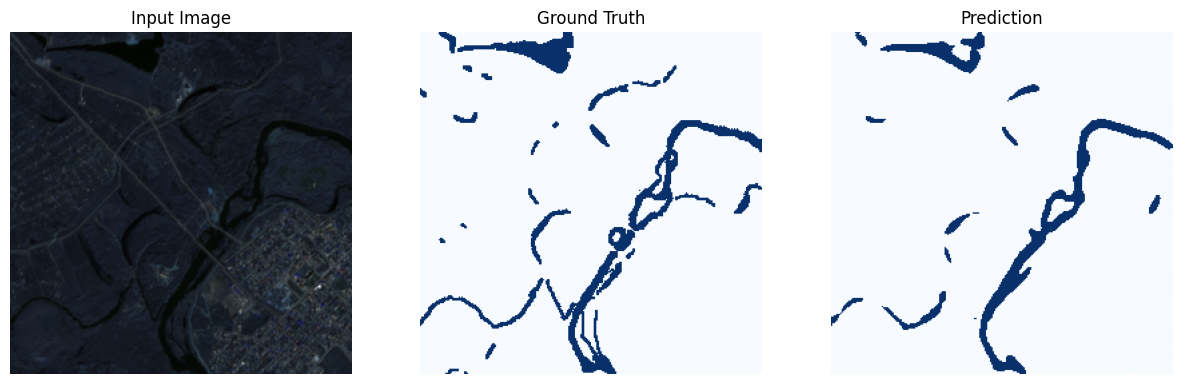

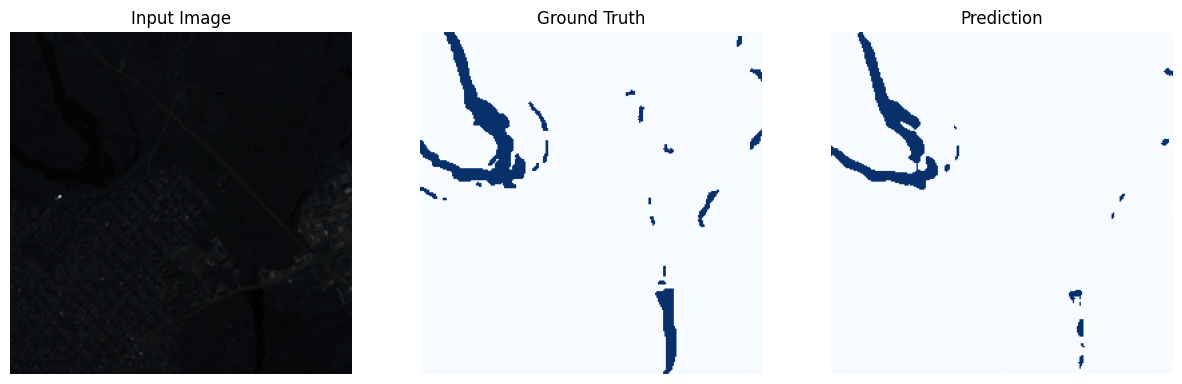

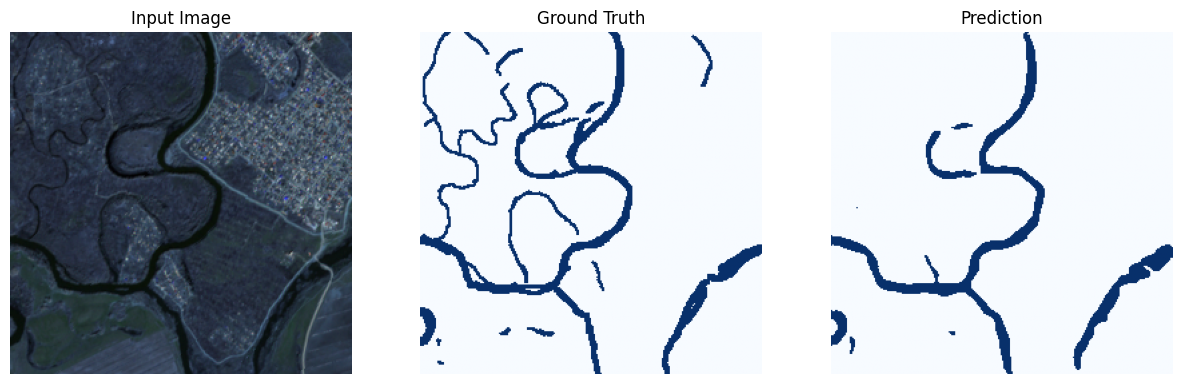

In [46]:
visualize_predictions(model, test_ds_raw, device)